# Examine structure of the cytoself manuscript data

In [1]:
# imports
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
os.getcwd()

'/home/shenrunx/igvf/varchamp/cytoself_varchamp/notebooks'

## 1. Loading some example data from README.md

In [2]:
# data paths
sample_dir = "../data/external/example_data"

In [3]:
meta = pl.read_csv(f"{sample_dir}/Label_data00.csv")
dat = np.load(f"{sample_dir}/Image_data00.npy", allow_pickle=True)

In [4]:
meta.head()

ensg,name,loc_grade1,loc_grade2,loc_grade3,protein_id,FOV_id
str,str,str,str,str,i64,i64
"""ENSG00000075624""","""ACTB""","""membrane;cytoskeleton""","""cytoplasmic""",null,2,27979
"""ENSG00000075624""","""ACTB""","""membrane;cytoskeleton""","""cytoplasmic""",null,2,27979
"""ENSG00000075624""","""ACTB""","""membrane;cytoskeleton""","""cytoplasmic""",null,2,27979
"""ENSG00000075624""","""ACTB""","""membrane;cytoskeleton""","""cytoplasmic""",null,2,27979
"""ENSG00000075624""","""ACTB""","""membrane;cytoskeleton""","""cytoplasmic""",null,2,27979


In [5]:
dat.shape

(134304, 100, 100, 4)

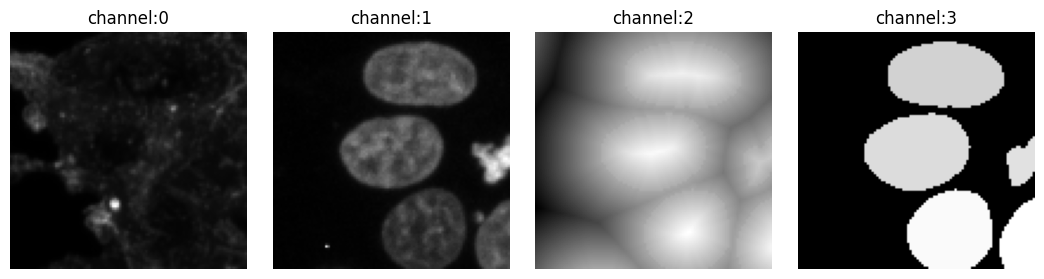

In [6]:
prot_ind = 1000
fig, ax = plt.subplots(1,4,figsize=(15,3))
for i in range(4):
    ax[i].imshow(dat[prot_ind, :, :, i], cmap='gray')  # Use 'gray' colormap for grayscale images
    ax[i].axis('off')  # Turn off axis labels
    ax[i].set_title(f"channel:{i}")
fig.subplots_adjust(wspace=-.3, hspace=-.1, top=.9)
plt.show()

From the images, I think that the channels are:
- 0 = protein
- 1 = nucleus
- 2 = distance map
- 3 = nuclear segmentation

In [7]:
# Check min and max values of prot and dna
print(dat[prot_ind, :, :, 0].max())
print(dat[prot_ind, :, :, 0].min())
print(dat[prot_ind, :, :, 1].max())
print(dat[prot_ind, :, :, 1].min())

0.8780097
0.0016630698
0.87525314
0.010707492


## 2. VarChAMP data

In [8]:
# Compare this to the example data structure
ex_meta = np.load(f"../data/interim/3_model_input/2025_07_B78-1112-1314-1516/ABCD1-Arg389Gly_label.npy", allow_pickle=True)
ex_nuc = np.load(f"../data/interim/3_model_input/2025_07_B78-1112-1314-1516/ABCD1-Arg389Gly_nuc.npy", allow_pickle=True)
ex_prot = np.load(f"../data/interim/3_model_input/2025_07_B78-1112-1314-1516/ABCD1-Arg389Gly_pro.npy", allow_pickle=True)

# Meta has #cells X 3 columns, each of three imaging npy have #cells X 100x100 pixels
# Need to find out if the pipeline will accept the concatenated data or if I need to split it & format like sample data in order to train the model. 

(-0.5, 99.5, 99.5, -0.5)

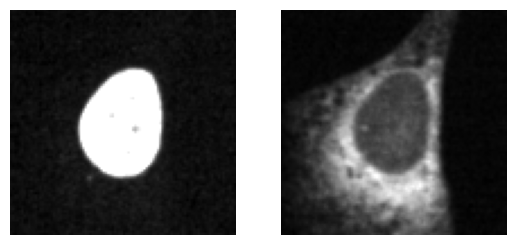

In [12]:
prot_ind = 22
fig, axes = plt.subplots(1,2)
axes[0].imshow(ex_nuc[prot_ind, :, :], cmap='gray')  # Use 'gray' colormap for grayscale images
axes[0].axis('off')  # Turn off axis labels
axes[1].imshow(ex_prot[prot_ind, :, :], cmap='gray')  # Use 'gray' colormap for grayscale images
axes[1].axis('off')  # Turn off axis labels

In [13]:
print(ex_meta.shape)
print(ex_nuc.shape)

(640, 2)
(640, 100, 100)


For cropping my own images, I would:

1. Filter out cells with bad nuclear area: cell area ratios
2. Get nuclear center coordinates for remaining cells. Filter out those within 100 pixels of the image edge
3. Create 100X100 crops of the protein and DNA channels
4. Probably skip distance maps because this means I don't need to do nuclear segmentation, and their ablation analysis showed modest improvement from this step. Need to see how to run model training without distance maps / nuclear segmentation channels.


Plan:
1. Get training running with original manuscript data. Verify that it works. 
2. Crop Varchamp images from batch
3. Perform heavy QA/QC filtering. Perhaps also develop filter to remove fully saturated/barely stained cells. 

In [48]:
from concurrent.futures import ThreadPoolExecutor
import threading
import warnings

def calculate_s2n_ratio_image(image_2d):
    """Calculate signal-to-noise ratio for a 2D image using 99th/25th percentile."""
    # Flatten the 2D image to 1D for percentile calculation
    pixels = image_2d.flatten()
    
    # Check for invalid values (NaN, inf, etc.)
    if not np.isfinite(pixels).all():
        # Filter out non-finite values
        pixels = pixels[np.isfinite(pixels)]
        if len(pixels) == 0:
            return np.nan
    
    # Suppress numpy warnings for this calculation
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        p99 = np.percentile(pixels, 99)
        p25 = np.percentile(pixels, 25)
    
    return p99 / p25 if p25 != 0 else np.inf

def calculate_s2n_ratio_threaded_3d(data_3d, n_threads=None):
    """
    Calculate s2n_ratio for each 2D image in a 3D array using threading.
    
    Parameters:
    - data_3d: 3D numpy array with shape (n_images, height, width)
    - n_threads: number of threads to use (default: 4)
    
    Returns:
    - numpy array of s2n_ratios for each image
    """
    if n_threads is None:
        n_threads = min(4, data_3d.shape[0])  # Use at most 4 threads or number of images
    
    with ThreadPoolExecutor(max_workers=n_threads) as executor:
        s2n_ratios = list(executor.map(calculate_s2n_ratio_image, data_3d))
    
    return np.array(s2n_ratios)

# Example usage with the loaded data
print(f"Original data shape: {dat.shape}")

# Calculate s2n ratios for protein channel (channel 0) for first 100 samples
protein_data = dat[:100, :, :, 0]  # First 100 images, protein channel
print(f"Protein data shape for s2n calculation: {protein_data.shape}")

# Check for any invalid values in the data
print(f"Contains NaN: {np.isnan(protein_data).any()}")
print(f"Contains inf: {np.isinf(protein_data).any()}")
print(f"All finite: {np.isfinite(protein_data).all()}")

# Calculate s2n ratios
protein_s2n = calculate_s2n_ratio_threaded_3d(protein_data)
print(f"S2N ratios shape: {protein_s2n.shape}")
print(f"S2N ratios (first 10): {protein_s2n[:10]}")
print(f"Mean S2N ratio: {np.nanmean(protein_s2n):.3f}")
print(f"Std S2N ratio: {np.nanstd(protein_s2n):.3f}")
print(f"Valid ratios: {np.isfinite(protein_s2n).sum()}/{len(protein_s2n)}")

# Also calculate for nucleus channel (channel 1) as comparison
nucleus_data = dat[:, :, :, 1]
prot_data = dat[:, :, :, 0]
nucleus_s2n = calculate_s2n_ratio_threaded_3d(nucleus_data)
prot_s2n = calculate_s2n_ratio_threaded_3d(prot_data)
print(f"\nNucleus channel S2N - Mean: {np.nanmean(nucleus_s2n):.3f}, Std: {np.nanstd(nucleus_s2n):.3f}")

Original data shape: (134304, 100, 100, 4)
Protein data shape for s2n calculation: (100, 100, 100)
Contains NaN: False
Contains inf: False
All finite: True
S2N ratios shape: (100,)
S2N ratios (first 10): [  5.58316343   9.25390116   7.14139976  51.17398474   8.93837686
   5.56707586 136.68135349  10.1164953    8.05223163  15.32128176]
Mean S2N ratio: 48.203
Std S2N ratio: 52.895
Valid ratios: 100/100

Nucleus channel S2N - Mean: 22.592, Std: 11.683


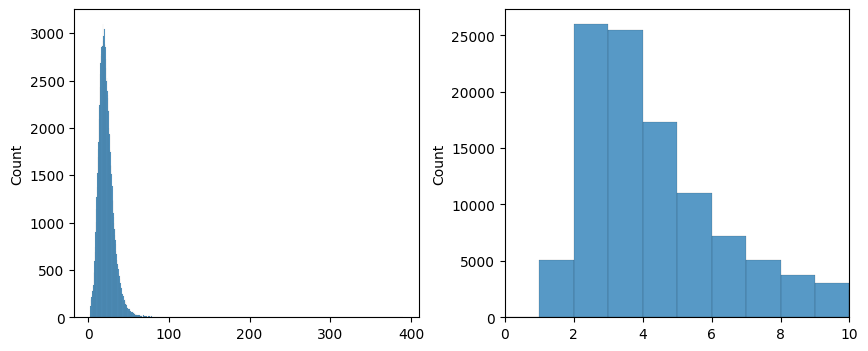

In [65]:
fig, ax = plt.subplots(1,2,figsize=(10,4))
sns.histplot(nucleus_s2n, ax=ax[0])
bin_edges = np.arange(0, np.ceil(prot_s2n.max()), 1)
sns.histplot(prot_s2n, bins=bin_edges, ax=ax[1])
ax[1].set_xlim(0, 10)
plt.subplots_adjust(wspace=0.25)

In [51]:
prot_s2n.shape

(134304,)

In [56]:
nucleus_s2n_vc = calculate_s2n_ratio_threaded_3d(ex_nuc)
prot_s2n_vc = calculate_s2n_ratio_threaded_3d(ex_prot)
print(f"\nNucleus channel S2N - Mean: {np.nanmean(nucleus_s2n_vc):.3f}, Std: {np.nanstd(nucleus_s2n_vc):.3f}")
print(f"\nProtein channel S2N - Mean: {np.nanmean(prot_s2n_vc):.3f}, Std: {np.nanstd(prot_s2n_vc):.3f}")


Nucleus channel S2N - Mean: 7.072, Std: 2.217

Protein channel S2N - Mean: 5.772, Std: 4.603


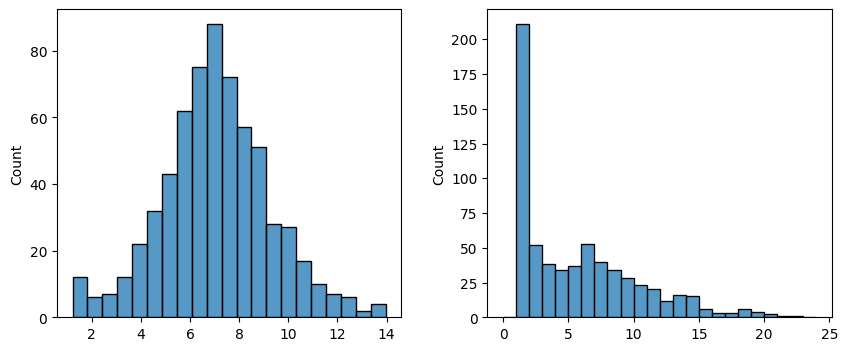

In [64]:
fig, ax = plt.subplots(1,2,figsize=(10,4))
sns.histplot(nucleus_s2n_vc, ax=ax[0])
bin_edges = np.arange(0, np.ceil(prot_s2n_vc.max()), 1)
sns.histplot(prot_s2n_vc, bins=bin_edges, ax=ax[1])
# ax[1].set_xlim(0, 10)
plt.subplots_adjust(wspace=0.25)

In [58]:
prot_s2n_vc.min()

1.326530612244898

In [59]:
prot_s2n.min()

1.077927546012472